In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Dict, Any, Optional

In [2]:
cfg = {
    'N_TRAIN': 4000,
    'N_PRED': 1000,
    'DT': 0.05,
    'MAX_FREQ': 1.5,          # Порог отсечения высокочастотного шума
    'ENERGY_FRAC': 0.99,      # Доля сохраняемой энергии
    'MAX_COMPONENTS': 30,     # Макс. число гармоник
    'NOISE_THRESHOLD': 1e-10  # Мин. амплитуда для учёта
}

In [3]:
N_TRAIN, N_PRED, DT = cfg['N_TRAIN'], cfg['N_PRED'], cfg['DT']
MAX_FREQ = cfg['MAX_FREQ']
ENERGY_FRAC = cfg['ENERGY_FRAC']
MAX_COMP = cfg['MAX_COMPONENTS']
NOISE_THR = cfg['NOISE_THRESHOLD']

In [4]:
print("Загрузка данных...")
test_data = pd.read_csv('test.csv', header=None).values.astype(np.float64)
etalon_test = pd.read_csv('etalon_for_test.csv', header=None).values.astype(np.float64)

L = test_data.shape[0]
y_train = test_data[:, :N_TRAIN]
y_true = etalon_test[:, N_TRAIN:N_TRAIN+N_PRED]

time_pred = np.arange(N_TRAIN, N_TRAIN + N_PRED) * DT
freqs = np.fft.rfftfreq(N_TRAIN, DT)
freq_mask = freqs <= MAX_FREQ

Загрузка данных...


In [7]:
print(f"Запуск векторизованного FFT-прогноза ({L} сигналов)...")
start_time = time.time()

# 1. Векторизованный FFT для всех сигналов одновременно
y_mean = np.mean(y_train, axis=1, keepdims=True)
y_centered = y_train - y_mean
Yf_all = np.fft.rfft(y_centered, axis=1)

# 2. Частотная фильтрация (мгновенно для всей матрицы)
Yf_all[:, ~freq_mask] = 0.0

predictions = np.zeros((L, N_PRED))

sample_spectrum = None
sample_components = None

# 3. Адаптивный отбор по энергии + реконструкция
for k in range(L):
    Yf = Yf_all[k].copy()

    power = np.abs(Yf) ** 2
    total_energy = power.sum()
    cut_idx = len(Yf)
    if total_energy > NOISE_THR:
        cum_energy = np.cumsum(power)
        cut_idx = np.searchsorted(cum_energy, total_energy * ENERGY_FRAC)
        cut_idx = min(cut_idx, MAX_COMP)
        Yf[cut_idx:] = 0.0

    valid = np.abs(Yf) > NOISE_THR
    if valid.any():
        Yf_v = Yf[valid]
        freqs_v = freqs[valid]

        amps = np.abs(Yf_v) * 2 / N_TRAIN
        if len(freqs_v) > 0 and np.isclose(freqs_v[0], 0.0):
            amps[0] /= 2
        if len(freqs_v) > 0 and np.isclose(freqs_v[-1], 0.5/DT):
            amps[-1] /= 2

        phases = np.angle(Yf_v)
        
        arg = 2 * np.pi * freqs_v[:, None] * time_pred[None, :] + phases[:, None]
        predictions[k] = amps @ np.cos(arg)
        
        if k == 0:
            sample_components = {
                'freqs': freqs_v.copy(),
                'amps': amps.copy(),
                'phases': phases.copy(),
                'time_pred': time_pred.copy(),
                'contributions': amps[:, None] * np.cos(arg)
            }

    predictions[k] += y_mean[k, 0]
    
    if k == 0:
        sample_spectrum = {
            'freqs': freqs.copy(),
            'amplitudes': np.abs(Yf_all[0]) * 2 / N_TRAIN,
            'power': np.abs(Yf_all[0])**2,
            'cut_idx': cut_idx,
            'freq_mask': freq_mask.copy()
        }

    if (k + 1) % 100 == 0 or k == L - 1:
        print(f"   Обработано: {k+1}/{L} сигналов")

elapsed = time.time() - start_time
print(f"Прогноз завершен за {elapsed:.3f} сек ({L/elapsed:.1f} сиг/сек)")

Запуск векторизованного FFT-прогноза (500 сигналов)...
   Обработано: 100/500 сигналов
   Обработано: 200/500 сигналов
   Обработано: 300/500 сигналов
   Обработано: 400/500 сигналов
   Обработано: 500/500 сигналов
Прогноз завершен за 0.114 сек (4380.7 сиг/сек)


In [ ]:
#Метрики
errors = predictions - y_true
rmse_global = np.sqrt(np.mean(errors**2))
bias_global = np.mean(errors)
mae_global = np.mean(np.abs(errors))
rmse_curve = np.sqrt(np.mean(errors**2, axis=0))

signal_range = np.ptp(y_true)
nrmse = rmse_global / signal_range if signal_range > 0 else 0.0
mape = np.mean(np.abs(errors) / (np.abs(y_true) + 1e-8)) * 100

print(f"\nИТОГОВЫЕ МЕТРИКИ:")
print(f"   Глобальная RMSE    : {rmse_global:.6f}")
print(f"   NRMSE (% размаха)  : {nrmse*100:.2f}%")
print(f"   Среднее смещение   : {bias_global:.6f}")
print(f"   MAE                : {mae_global:.6f}")
print(f"   MAPE               : {mape:.2f}%")
print(f"   Макс. СКП (t=50с)  : {rmse_curve[-1]:.6f}")


ИТОГОВЫЕ МЕТРИКИ:
   Глобальная RMSE    : 0.728433
   NRMSE (% размаха)  : 17.81%
   Среднее смещение   : 0.009993
   MAE                : 0.579826
   MAPE               : 934.90%
   Макс. СКП (t=50с)  : 0.764256


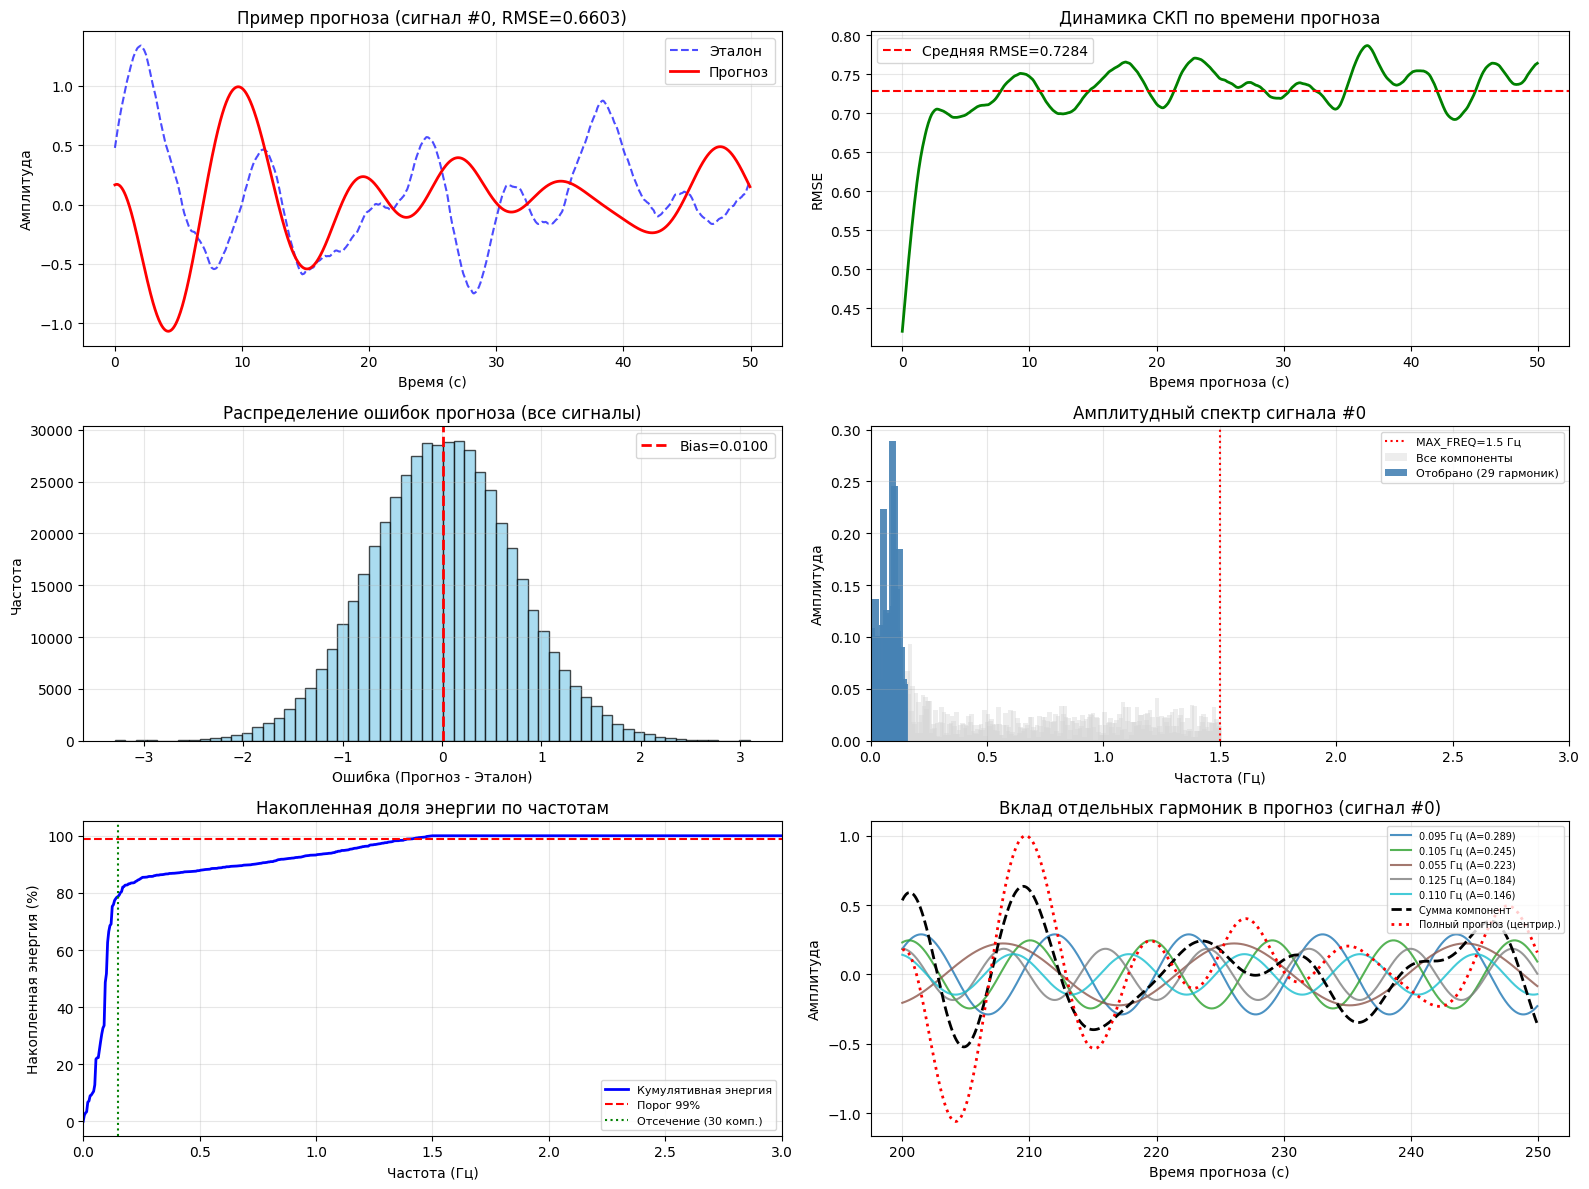

In [ ]:
plt.figure(figsize=(16, 12))
t_axis = np.arange(N_PRED) * DT

# График 1: Пример прогноза
plt.subplot(3, 2, 1)
plt.plot(t_axis, y_true[0], 'b--', alpha=0.7, label='Эталон', linewidth=1.5)
plt.plot(t_axis, predictions[0], 'r-', linewidth=2, label='Прогноз')
plt.title(f"Пример прогноза (сигнал #0, RMSE={np.sqrt(np.mean(errors[0]**2)):.4f})")
plt.xlabel("Время (с)")
plt.ylabel("Амплитуда")
plt.grid(True, alpha=0.3)
plt.legend()

# График 2: Динамика СКП
plt.subplot(3, 2, 2)
plt.plot(t_axis, rmse_curve, 'g-', linewidth=2)
plt.axhline(rmse_global, color='red', linestyle='--', label=f'Средняя RMSE={rmse_global:.4f}')
plt.title("Динамика СКП по времени прогноза")
plt.xlabel("Время прогноза (с)")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.legend()

# График 3: Распределение ошибок
plt.subplot(3, 2, 3)
plt.hist(errors.ravel(), bins=60, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(bias_global, color='red', linestyle='--', linewidth=2, label=f'Bias={bias_global:.4f}')
plt.title("Распределение ошибок прогноза (все сигналы)")
plt.xlabel("Ошибка (Прогноз - Эталон)")
plt.ylabel("Частота")
plt.grid(True, alpha=0.3)
plt.legend()

if sample_spectrum is not None and sample_components is not None:
    # График 4: Амплитудный спектр с выделенными компонентами
    plt.subplot(3, 2, 4)
    spec = sample_spectrum
    plt.bar(spec['freqs'], spec['amplitudes'], width=0.02, alpha=0.4, label='Все компоненты', color='lightgray')

    valid_mask = np.abs(Yf_all[0]) > NOISE_THR
    selected_freqs = spec['freqs'][:spec['cut_idx']][valid_mask[:spec['cut_idx']]]
    selected_amps = spec['amplitudes'][:spec['cut_idx']][valid_mask[:spec['cut_idx']]]
    plt.bar(selected_freqs, selected_amps, width=0.03, alpha=0.9, label=f'Отобрано ({len(selected_freqs)} гармоник)', color='steelblue')

    plt.axvline(MAX_FREQ, color='red', linestyle=':', label=f'MAX_FREQ={MAX_FREQ} Гц')
    plt.title("Амплитудный спектр сигнала #0")
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Амплитуда")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.xlim(0, min(3, freqs[-1]))

    # График 5: Кумулятивная энергия
    plt.subplot(3, 2, 5)
    power = sample_spectrum['power']
    cum_energy = np.cumsum(power) / power.sum() * 100
    plt.plot(freqs, cum_energy, 'b-', linewidth=2, label='Кумулятивная энергия')
    plt.axhline(ENERGY_FRAC * 100, color='red', linestyle='--', label=f'Порог {ENERGY_FRAC*100:.0f}%')
    plt.axvline(spec['freqs'][min(spec['cut_idx'], len(freqs)-1)], color='green', linestyle=':', 
            label=f'Отсечение ({spec["cut_idx"]} комп.)')
    plt.title("Накопленная доля энергии по частотам")
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Накопленная энергия (%)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.xlim(0, min(3, freqs[-1]))

    # График 6: Вклад отдельных гармоник в прогноз
    plt.subplot(3, 2, 6)
    comp = sample_components
    n_show = min(5, len(comp['freqs']))

    colors = plt.cm.tab10(np.linspace(0, 1, n_show))
    for i in range(n_show):
        idx = np.argsort(comp['amps'])[-(i+1)]
        plt.plot(comp['time_pred'], comp['contributions'][idx], 
                color=colors[i], linewidth=1.5, alpha=0.8,
                label=f'{comp["freqs"][idx]:.3f} Гц (A={comp["amps"][idx]:.3f})')

    # Сумма показанных компонент
    top_indices = np.argsort(comp['amps'])[-n_show:]
    sum_contrib = np.sum(comp['contributions'][top_indices], axis=0)
    plt.plot(comp['time_pred'], sum_contrib, 'k--', linewidth=2, label='Сумма компонент')

    # Полный прогноз для сравнения
    plt.plot(comp['time_pred'], predictions[0] - y_mean[0, 0], 'r:', linewidth=2, label='Полный прогноз (центрир.)')

    plt.title("Вклад отдельных гармоник в прогноз (сигнал #0)")
    plt.xlabel("Время прогноза (с)")
    plt.ylabel("Амплитуда")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=7, loc='upper right')


plt.tight_layout()
plt.show()

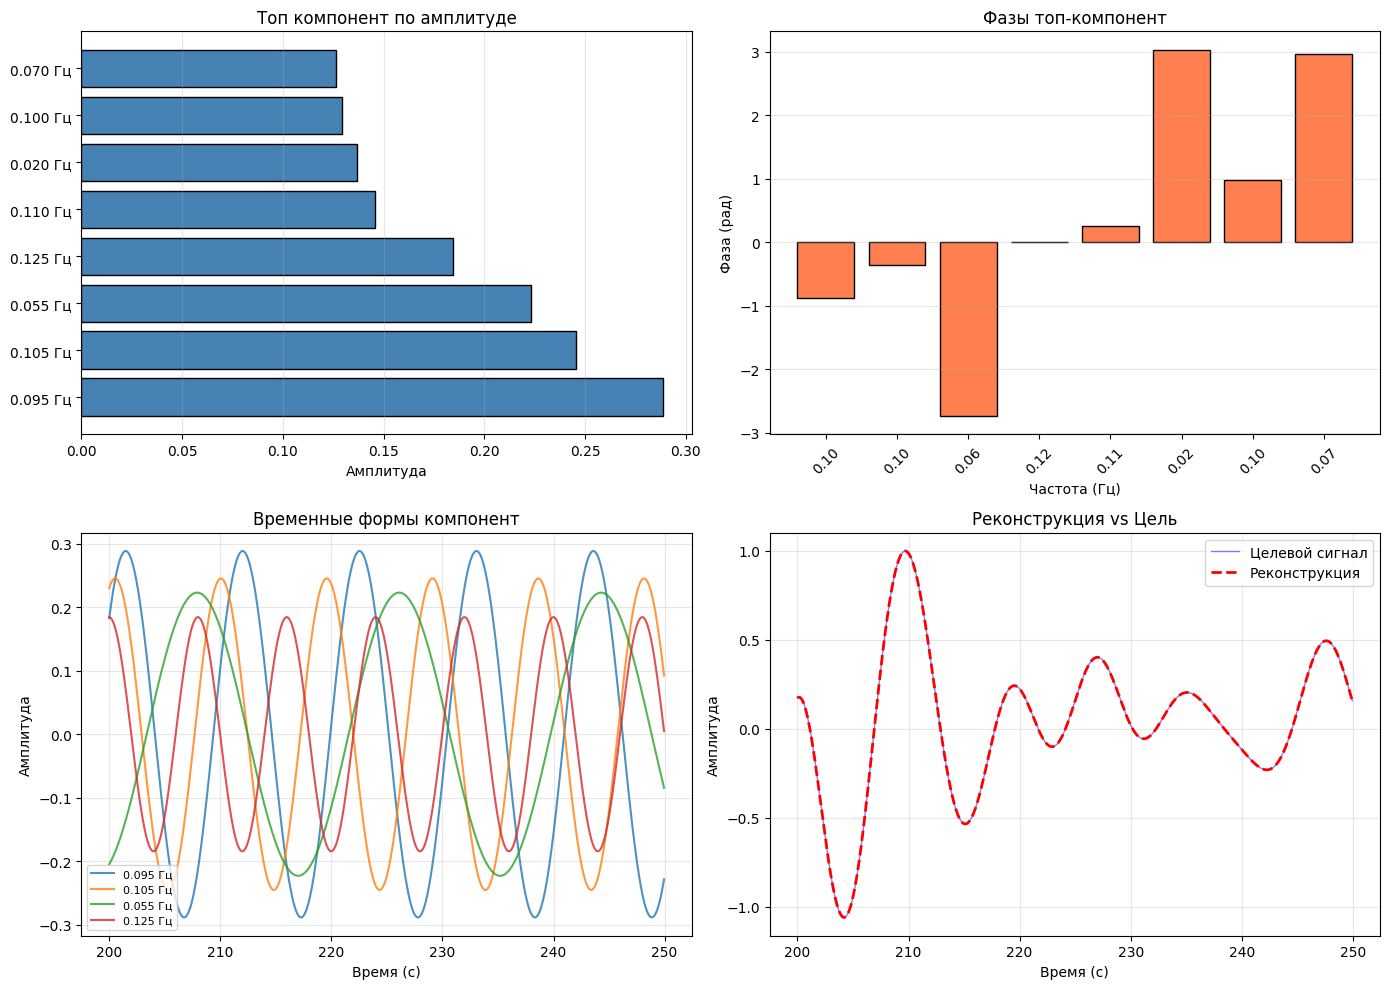

In [ ]:
comp = sample_components
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Топ-компоненты по амплитуде
n_top = min(8, len(comp['freqs']))
top_idx = np.argsort(comp['amps'])[-n_top:][::-1]

# График 7: Амплитуды топ-компонент
ax = axes[0, 0]
bars = ax.barh(range(n_top), comp['amps'][top_idx], color='steelblue', edgecolor='black')
ax.set_yticks(range(n_top))
ax.set_yticklabels([f'{comp["freqs"][i]:.3f} Гц' for i in top_idx])
ax.set_xlabel('Амплитуда')
ax.set_title('Топ компонент по амплитуде')
ax.grid(True, alpha=0.3, axis='x')

# График 9: Фазы топ-компонент
ax = axes[0, 1]
ax.bar(range(n_top), comp['phases'][top_idx], color='coral', edgecolor='black')
ax.set_xticks(range(n_top))
ax.set_xticklabels([f'{comp["freqs"][i]:.2f}' for i in top_idx], rotation=45)
ax.set_xlabel('Частота (Гц)')
ax.set_ylabel('Фаза (рад)')
ax.set_title('Фазы топ-компонент')
ax.grid(True, alpha=0.3, axis='y')

# График 10: Временные формы компонент
ax = axes[1, 0]
for i in range(min(4, n_top)):
    idx = top_idx[i]
    ax.plot(comp['time_pred'], comp['contributions'][idx], 
        label=f'{comp["freqs"][idx]:.3f} Гц', alpha=0.8)
ax.set_xlabel('Время (с)')
ax.set_ylabel('Амплитуда')
ax.set_title('Временные формы компонент')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# График 11: Остаток после вычитания компонент
ax = axes[1, 1]
reconstructed = np.sum(comp['contributions'], axis=0)
target = predictions[0] - y_mean[0, 0]
ax.plot(comp['time_pred'], target, 'b-', alpha=0.5, label='Целевой сигнал', linewidth=1)
ax.plot(comp['time_pred'], reconstructed, 'r--', label='Реконструкция', linewidth=2)
ax.set_xlabel('Время (с)')
ax.set_ylabel('Амплитуда')
ax.set_title('Реконструкция vs Цель')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()